In [23]:
import numpy as np
import scipy
from netCDF4 import Dataset
from matplotlib import pyplot as plt
import xarray as xr
import matplotlib.colors as colors
import metpy
import cmaps
import matplotlib

In [24]:
# Manually add the wavespeeds 

# Which test are we looking at??
#test = 'p_pert'
test = 'acid'

# Model top heights
zT_range = np.linspace(10, 120, 1000)
zT_vals = ([12.5, 25, 50, 100])

In [25]:
if test == 'p_pert':
    se_speeds = np.array([310, 315, 320, 325])
    fv3_speeds = np.array([305, 310, 324, 325])
    mpas_speeds = np.array([330,330,330,330])
elif test == 'acid':
    se_speeds = np.array([310, 315, 320, 325])
    fv3_speeds = np.array([310, 315, 320, 325])
    mpas_speeds = np.array([330,330,330,330])

In [26]:
# Theoretical Lamb wave speed with no model top dependence
gamma = 7./5.
R_d = 287.04
T0 = 275
lamb_speed = np.sqrt(gamma*R_d*T0)
lamb_speed_array = lamb_speed*np.ones(len(zT_range))

print(f'Expected Lamb wave speed is {lamb_speed}')

Expected Lamb wave speed is 332.4310454816156


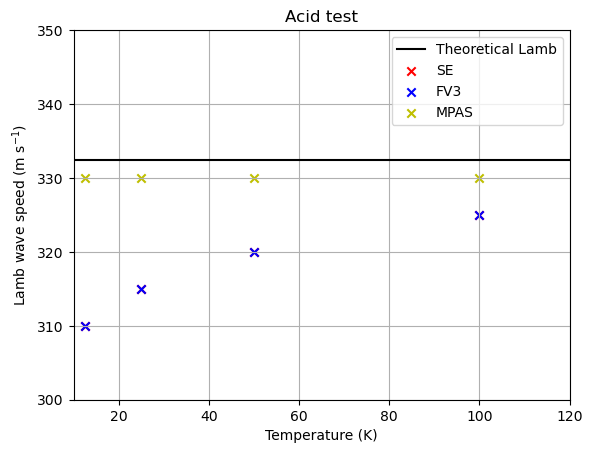

In [27]:
# Make the figure
plt.figure()
plt.plot(zT_range, lamb_speed_array, c='k', label='Theoretical Lamb')
#plt.plot(zT_range, lamb_speed*, c='k', label='Theoretical with mixed BCs')
plt.scatter(zT_vals, se_speeds, c = 'r', marker = 'x', label='SE')
plt.scatter(zT_vals, fv3_speeds, c = 'b', marker = 'x', label='FV3')
plt.scatter(zT_vals, mpas_speeds, c = 'y', marker = 'x', label='MPAS')

if test == 'p_pert':
    plt.title('Test case 1')
elif test == 'acid':
    plt.title('Test case 2')

plt.xlabel('Temperature (K)')
plt.ylabel(r'Lamb wave speed (m s$^{-1}$)')
plt.xlim([10,120])
plt.ylim([300,350])

plt.legend()
plt.grid()

if test == 'p_pert':
    plt.title('Pressure perturbation test')
    plt.savefig(f'figures/p_pert_speeds_with_ztop.jpg', bbox_inches='tight')
elif test == 'acid':
    plt.title('Acid test')
    plt.savefig(f'figures/acid_speeds_with_ztop.jpg', bbox_inches='tight')

plt.show()
